# Clustering with K-means
Learning Goals:
- Understand how K-means clusters data in 2-dimensional feature space.
- Apply K-means clustering to classify satellite pixels.
- Visualise results in 2D.



_______________________________________________________________________________
# K-means on synthetic data
First, let us generate some fake data that does not have labels but that does have a clear clustering structure within it.

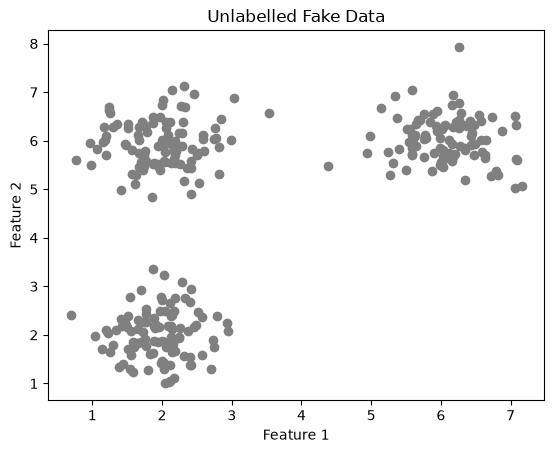

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Generate 3 clusters of 2D points
np.random.seed(42)
cluster_1 = np.random.normal(loc=[2, 2], scale=0.5, size=(100, 2))
cluster_2 = np.random.normal(loc=[6, 6], scale=0.5, size=(100, 2))
cluster_3 = np.random.normal(loc=[2, 6], scale=0.5, size=(100, 2))

data = np.vstack((cluster_1, cluster_2, cluster_3))

# Plot the unlabelled data
plt.scatter(data[:, 0], data[:, 1], c='gray')
plt.title("Unlabelled Fake Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

(100, 2)

Next, apply the K-means algorithim.

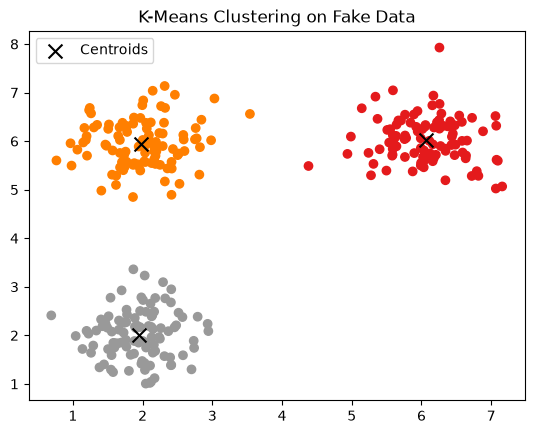

In [4]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(data)
labels = kmeans.labels_

# Visualize the clustering
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='Set1')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='x', s=100, label='Centroids')
plt.title("K-Means Clustering on Fake Data")
plt.legend()
plt.show()

Let's move some of these clusters closer to each other...

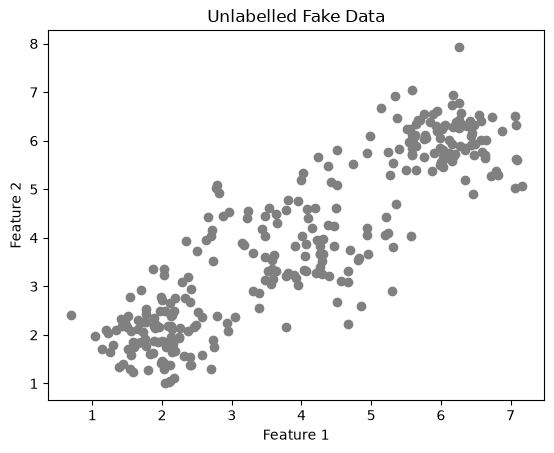

In [9]:
# Generate 3 clusters of 2D points that overlap
np.random.seed(42)
cluster_1 = np.random.normal(loc=[2, 2], scale=0.5, size=(100, 2))
cluster_2 = np.random.normal(loc=[6, 6], scale=0.5, size=(100, 2))
cluster_3 = np.random.normal(loc=[4, 4], scale=0.8, size=(100, 2)) #<- Here is where I moved (loc) the third cluster to sit between the other two and dispersed it further (scale)

data = np.vstack((cluster_1, cluster_2, cluster_3))

# Plot the unlabelled data
plt.scatter(data[:, 0], data[:, 1], c='gray')
plt.title("Unlabelled Fake Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

Let us apply the K-means once more....

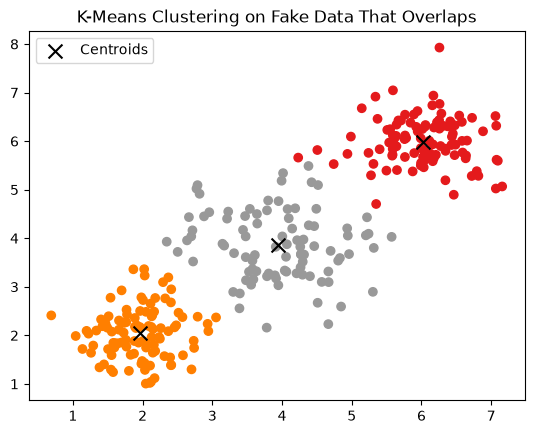

In [10]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(data)
labels = kmeans.labels_

# Visualize the clustering
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='Set1')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='x', s=100, label='Centroids')
plt.title("K-Means Clustering on Fake Data That Overlaps")
plt.legend()
plt.show()

Exercise: alter the dispersion and position of the first cluster so that it interacts more with the third. Do this by:
*   Set the position to [3,2] and the scale (dispersion) to 0.6

As a pair, discuss if the resulting clusters that are found are truly meaninful?Should this data now be two clusters rather than three?

Then, add a fourth cluster to our synthetic data:
*   At position [2,7] with scale 0.5, but leave k-means set to n_clusters=3.

Does the resulting clustering change your answer to the above question?

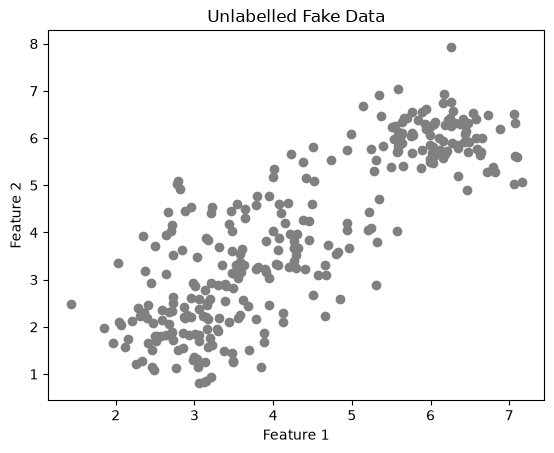

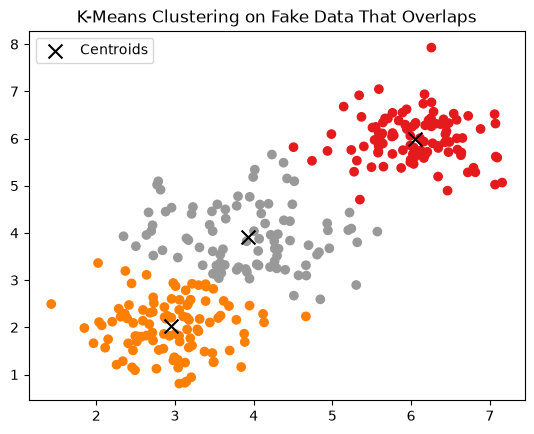

In [15]:
# Use this code cell to copy in the example code above and modify it to answer the k-means exercise so that you can compare results more easily
# Generate 3 clusters of 2D points that overlap
np.random.seed(42)
cluster_1 = np.random.normal(loc=[3, 2], scale=0.6, size=(100, 2))
cluster_2 = np.random.normal(loc=[6, 6], scale=0.5, size=(100, 2))
cluster_3 = np.random.normal(loc=[4, 4], scale=0.8, size=(100, 2)) #<- Here is where I moved (loc) the third cluster to sit between the other two and dispersed it further (scale)

data = np.vstack((cluster_1, cluster_2, cluster_3))

# Plot the unlabelled data
plt.scatter(data[:, 0], data[:, 1], c='gray')
plt.title("Unlabelled Fake Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=0).fit(data)
labels = kmeans.labels_

# Visualize the clustering
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='Set1')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='x', s=100, label='Centroids')
plt.title("K-Means Clustering on Fake Data That Overlaps")
plt.legend()
plt.show()

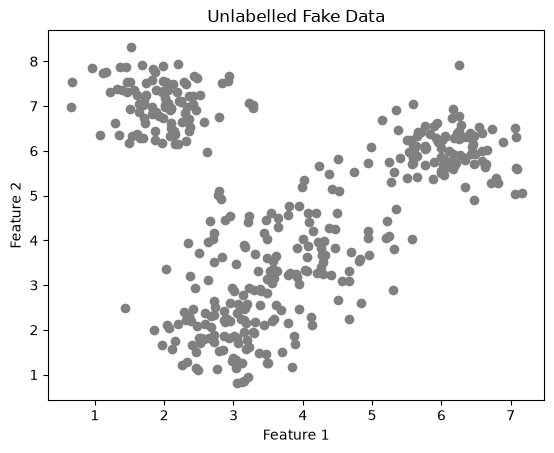

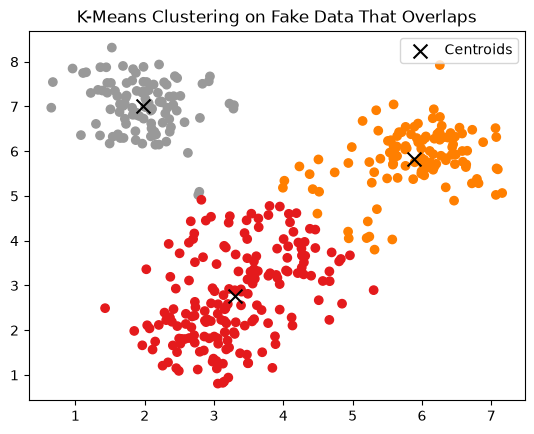

In [17]:
# Use this code cell to copy in the example code above and modify it to answer the k-means exercise so that you can compare results more easily
# Generate 3 clusters of 2D points that overlap
np.random.seed(42)
cluster_1 = np.random.normal(loc=[3, 2], scale=0.6, size=(100, 2))
cluster_2 = np.random.normal(loc=[6, 6], scale=0.5, size=(100, 2))
cluster_3 = np.random.normal(loc=[4, 4], scale=0.8, size=(100, 2)) #<- Here is where I moved (loc) the third cluster to sit between the other two and dispersed it further (scale)
cluster_4 = np.random.normal(loc=[2, 7], scale=0.5, size=(100, 2))

data = np.vstack((cluster_1, cluster_2, cluster_3,cluster_4))

# Plot the unlabelled data
plt.scatter(data[:, 0], data[:, 1], c='gray')
plt.title("Unlabelled Fake Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

kmeans = KMeans(n_clusters=3, random_state=0).fit(data)
labels = kmeans.labels_

# Visualize the clustering
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='Set1')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='black', marker='x', s=100, label='Centroids')
plt.title("K-Means Clustering on Fake Data That Overlaps")
plt.legend()
plt.show()

________________________________________________________________________________
# K-means on Sentinel 2
Now we will have a first run at applying un-supervised classification on satellite data.

In [18]:
# Our usual set up for ee and geemap
import ee
import geemap

ee.Authenticate()
ee.Initialize(project='geog761-dongwook') #<- Remember to change this to your own project's name!

Load Sentinel 2 and grab the bands we want from the area we want:

In [37]:
# Auckland area
point = ee.Geometry.Point([174.7633, -36.8485])
image = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(point) \
    .filterDate('2023-02-01', '2023-02-28') \
    .sort('CLOUD_COVER') \
    .first()

# Select relevant bands and reduce size
bands = image.select(['B2', 'B3', 'B4', 'B8'])  # Blue, Green, Red, NIR
region = point.buffer(1000).bounds()  # small area for demo

# Sample image pixels to NumPy
sample = bands.sample(region=region, scale=10, numPixels=1000, seed=42).getInfo()
pixels = np.array([list(f['properties'].values()) for f in sample['features']])


In [33]:
image

Apply the K-means classifier, noting that we have pulled the pixels out of the earth engine server side to a numpy array on our client side. This is an important and likely common step for your future work in this module!

In [21]:
# Sklearn Kmeans alg
kmeans_sat = KMeans(n_clusters=4, random_state=0).fit(pixels)
labels_sat = kmeans_sat.labels_

Now let's visualize this in 2D Feature Space:

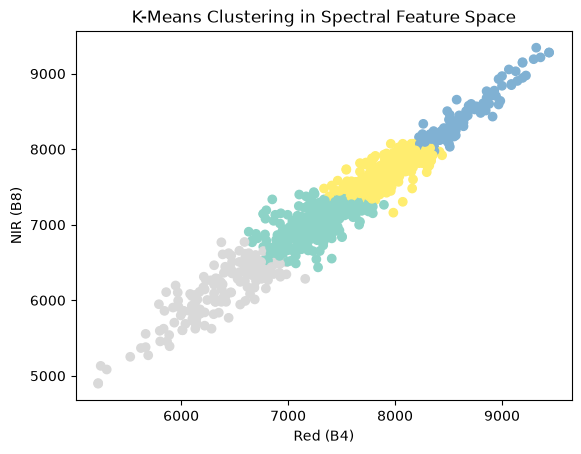

In [22]:
# Let's plot Red vs NIR as an example
plt.scatter(pixels[:, 2], pixels[:, 3], c=labels_sat, cmap='Set3')
plt.xlabel('Red (B4)')
plt.ylabel('NIR (B8)')
plt.title('K-Means Clustering in Spectral Feature Space')
plt.show()

In you pair, answer the following discussion prompts:
- What patterns did the K-means pick up in the image data?
- How might the choice of bands or number of clusters affect results?
- What are the risks of using K-means for landcover classification?

For the very keen beans, now plot the Sentinel 2 data with the pixels colored according the the classification of K-means. This is very much just an extension task!

In [165]:
num_clusters = 6
point = ee.Geometry.Point([174.7679, -36.8504]) # Albert Park
image = ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED') \
    .filterBounds(point) \
    .filterDate('2023-02-01', '2023-02-28') \
    .sort('HIGH_PROBA_CLOUDS_PERCENTAGE') \
    .first()

bands = image.select(['B2', 'B3', 'B4']).divide(10_000)  # Blue, Green, Red, NIR
region = point.buffer(500).bounds()  # small area for demo


samples = bands.sample(region=region, geometries=True, scale=30, numPixels=1000, seed=42).getInfo()


pixels = np.array([list(f['properties'].values()) for f in samples['features']])

sample_coord = [ (f['geometry']['coordinates'][0],f['geometry']['coordinates'][1]) for f in samples['features']]

kmeans_sat = KMeans(n_clusters=num_clusters, random_state=0).fit(pixels)
labels_sat = kmeans_sat.labels_



In [179]:
#(['B2', 'B3', 'B4', 'B8'])  # Blue, Green, Red, NIR
import pandas as pd
df_classified = pd.DataFrame({
    'longitude': [coord[0] for coord in sample_coord],
    'latitude': [coord[1] for coord in sample_coord],
    'cluster': labels_sat,
    'blue': pixels[:, 0],
    'green': pixels[:, 1],
    'red': pixels[:, 2]
    # 'nir': pixels[:, 3]
})


In [180]:
len(df_classified)

990

In [181]:
vis_params = {
    'min': 20,
    'max': 5000,
    'bands': ['B4', 'B3', 'B2'],
    'gamma': 1.5
}

# Display the true color image
Map = geemap.Map()
Map.centerObject(point, 12)

Map.addLayer(image, vis_params, 'True Color')

In [182]:
colors = ['red', 'blue', 'green', 'yellow','purple','orange']
# Create a single FeatureCollection for all points to improve performance
features = []
for cluster in range(num_clusters):
    cluster_data = df_classified[df_classified['cluster'] == cluster]
    cluster_features = [
        ee.Feature(
            ee.Geometry.Point([row['longitude'], row['latitude']]),
            {'cluster': cluster}
        )
        for _, row in cluster_data.iterrows()
    ]
    features.extend(cluster_features)

# Create a single FeatureCollection and add it as one layer per cluster
all_points = ee.FeatureCollection(features)

# Add each cluster as a separate layer using filtering
for cluster in range(num_clusters):
    cluster_points: ee.FeatureCollection = all_points.filter(ee.Filter.eq('cluster', cluster))
    Map.addLayer(cluster_points, {'color': colors[cluster]}, f'Cluster {cluster}', False)


In [183]:
Map

Map(center=[-36.8504, 174.7679], controls=(WidgetControl(options=['position', 'transparent_bg'], position='top…

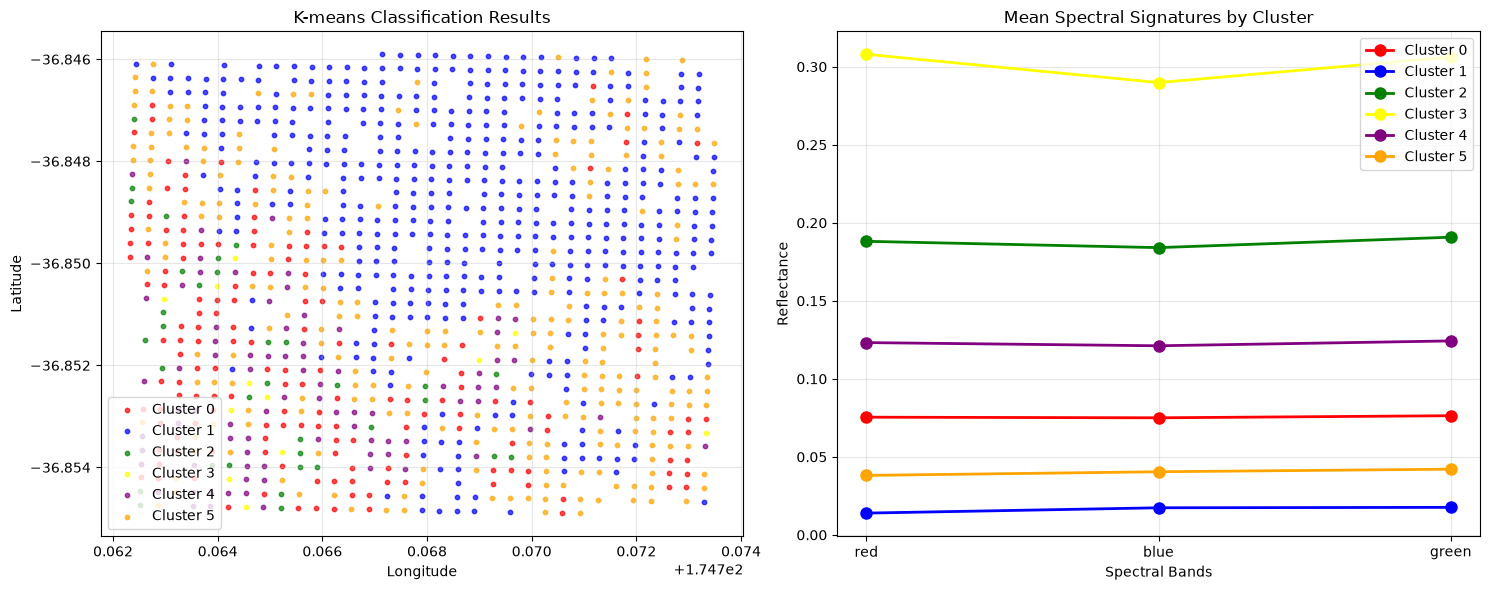

Classification completed with 990 pixels classified into 4 clusters

Cluster statistics:
Cluster 0: 158 pixels (16.0%)
Cluster 1: 451 pixels (45.6%)
Cluster 2: 34 pixels (3.4%)
Cluster 3: 12 pixels (1.2%)
Cluster 4: 83 pixels (8.4%)
Cluster 5: 252 pixels (25.5%)


In [184]:

# Also create a matplotlib plot showing the classification
import matplotlib.pyplot as plt
import numpy as np

# Create a scatter plot of the classified pixels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Original RGB composite (if we have the data)
# For now, we'll plot the classified points
colors_mpl = ['red', 'blue', 'green', 'yellow','purple','orange']
for cluster in range(num_clusters):
    cluster_data = df_classified[df_classified['cluster'] == cluster]
    ax1.scatter(cluster_data['longitude'], cluster_data['latitude'], 
               c=colors_mpl[cluster], label=f'Cluster {cluster}', alpha=0.7, s=10)

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('K-means Classification Results')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Spectral signatures by cluster
band_names = ['red', 'blue', 'green' ] 
for cluster in range(num_clusters):
    cluster_data = df_classified[df_classified['cluster'] == cluster]
    mean_values = cluster_data[band_names].mean()
    ax2.plot(band_names, mean_values, 'o-', color=colors_mpl[cluster], 
             label=f'Cluster {cluster}', linewidth=2, markersize=8)

ax2.set_xlabel('Spectral Bands')
ax2.set_ylabel('Reflectance')
ax2.set_title('Mean Spectral Signatures by Cluster')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Classification completed with {len(df_classified)} pixels classified into 4 clusters")
print("\nCluster statistics:")
for cluster in range(num_clusters):
    count = len(df_classified[df_classified['cluster'] == cluster])
    percentage = (count / len(df_classified)) * 100
    print(f"Cluster {cluster}: {count} pixels ({percentage:.1f}%)")